# Linear Regression: Machine Learning & Optimization Perspective

## What this notebook covers
1. **The Model** — hypothesis and loss function
2. **Normal Equation** — closed-form optimization
3. **Gradient Descent (GD)** — batch optimization
4. **Stochastic Gradient Descent (SGD)** — online optimization
5. **Learning Rate** — impact on convergence
6. **Cost Surface** — visualizing the optimization landscape
7. **Residual Diagnostics** — validating the fit

### The Setup
We assume a linear relationship:

$$y = \theta_0 + \theta_1 x + \epsilon$$

**Goal:** Find parameters $\theta$ that minimize the Mean Squared Error (MSE) cost function:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

where $m$ is the number of training examples.


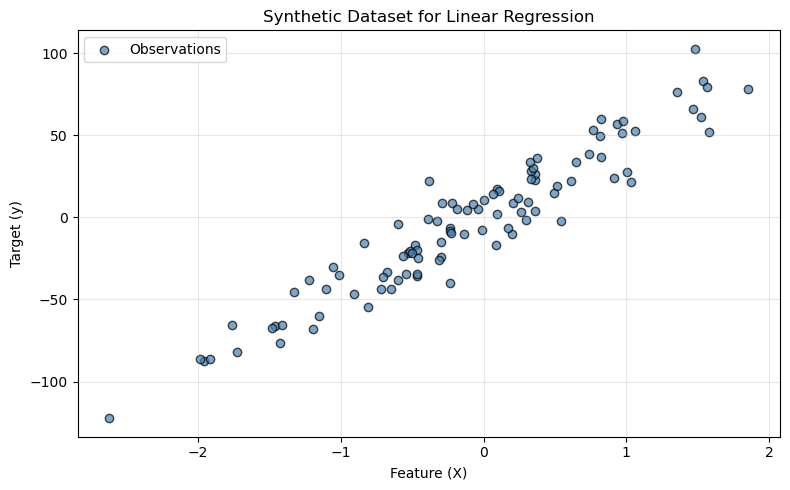

True coefficient (slope) from data generator: 41.7411


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic regression data
X, y, true_coef = make_regression(
    n_samples=100,
    n_features=1,
    noise=15,
    coef=True,
    random_state=42
)

# Flatten for 1-D visualization
X_flat = X.ravel()
y_flat = y

# Visualize raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_flat, y_flat, c='steelblue', edgecolors='k', alpha=0.7, label='Observations')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Synthetic Dataset for Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True coefficient (slope) from data generator: {true_coef:.4f}")


## 1. Normal Equation (Closed-Form Solution)

Instead of iterating, we can solve for the optimal $\theta$ analytically by setting the gradient of $J(\theta)$ to zero:

$$\theta = (X^T X)^{-1} X^T y$$

**Pros:** Exact solution in one step. No learning rate to tune.  
**Cons:** $O(n^3)$ complexity due to matrix inversion; becomes expensive with many features.

> **Note:** We prepend a column of ones to $X$ to account for the intercept $\theta_0$.


Normal Equation — Intercept (theta_0): 1.7477
Normal Equation — Slope (theta_1):     45.7852


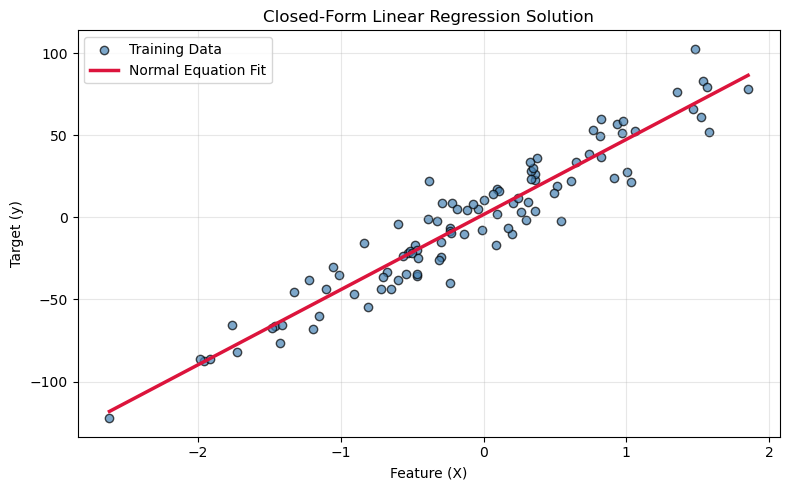

In [23]:
# Design matrix with bias term (column of ones)
X_b = np.c_[np.ones((len(X_flat), 1)), X_flat]

# Normal Equation
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_flat

print(f"Normal Equation — Intercept (theta_0): {theta_normal[0]:.4f}")
print(f"Normal Equation — Slope (theta_1):     {theta_normal[1]:.4f}")

# Generate smooth line for plotting
x_line = np.linspace(X_flat.min(), X_flat.max(), 100)
X_line_b = np.c_[np.ones((100, 1)), x_line]
y_pred_normal = X_line_b @ theta_normal

# Plot fit
plt.figure(figsize=(8, 5))
plt.scatter(X_flat, y_flat, c='steelblue', edgecolors='k', alpha=0.7, label='Training Data')
plt.plot(x_line, y_pred_normal, color='crimson', linewidth=2.5, label='Normal Equation Fit')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Closed-Form Linear Regression Solution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Batch Gradient Descent

When the dataset is too large for the Normal Equation, we use **iterative optimization**.

**Update rule:**
$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

For linear regression, the gradient simplifies to:

$$\frac{\partial J}{\partial \theta} = \frac{1}{m} X^T (X\theta - y)$$

We repeatedly update $\theta$ until $J(\theta)$ converges.


Batch GD — Intercept: 1.4999
Batch GD — Slope:     45.0918


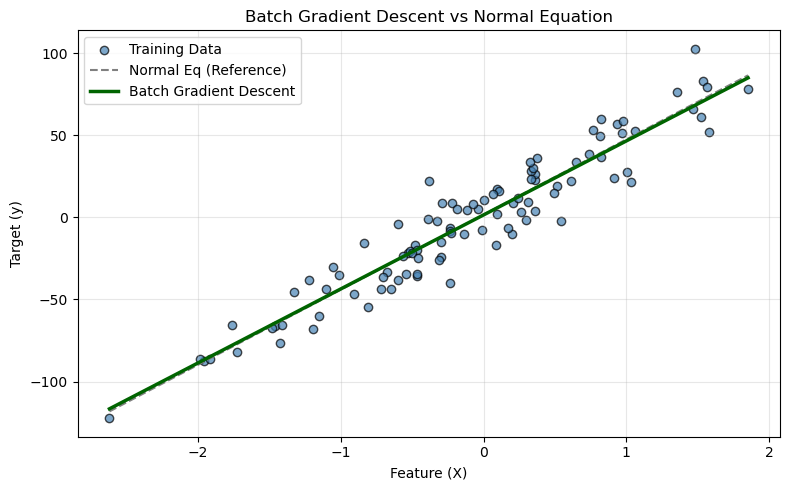

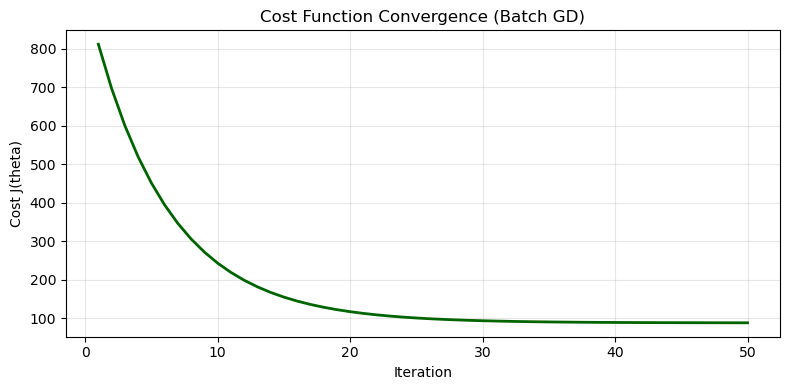

In [24]:
def compute_cost(X, y, theta):
    """Mean Squared Error cost function (with 1/2m factor)."""
    m = len(y)
    errors = X @ theta - y
    return (1 / (2 * m)) * np.sum(errors ** 2)


def gradient_descent(X, y, theta_init, learning_rate=0.01, n_iterations=1000):
    """Batch Gradient Descent."""
    m = len(y)
    theta = theta_init.copy()
    cost_history = np.zeros(n_iterations)
    theta_history = np.zeros((n_iterations, 2))
    
    for i in range(n_iterations):
        gradients = (1 / m) * X.T @ (X @ theta - y)
        theta = theta - learning_rate * gradients
        cost_history[i] = compute_cost(X, y, theta)
        theta_history[i] = theta
        
    return theta, cost_history, theta_history


# Run Batch GD
theta_init = np.zeros(2)
theta_gd, cost_history, theta_history = gradient_descent(
    X_b, y_flat, theta_init, learning_rate=0.1, n_iterations=50
)

print(f"Batch GD — Intercept: {theta_gd[0]:.4f}")
print(f"Batch GD — Slope:     {theta_gd[1]:.4f}")

# Predictions using GD parameters
y_pred_gd = X_line_b @ theta_gd

# Plot comparison
plt.figure(figsize=(8, 5))
plt.scatter(X_flat, y_flat, c='steelblue', edgecolors='k', alpha=0.7, label='Training Data')
plt.plot(x_line, y_pred_normal, color='gray', linestyle='--', linewidth=1.5, label='Normal Eq (Reference)')
plt.plot(x_line, y_pred_gd, color='darkgreen', linewidth=2.5, label='Batch Gradient Descent')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Batch Gradient Descent vs Normal Equation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Convergence curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cost_history) + 1), cost_history, color='darkgreen', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Cost Function Convergence (Batch GD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. The Learning Rate

The learning rate $\alpha$ controls the step size.  
- **Too small:** Slow convergence.  
- **Too large:** Overshooting, divergence, or oscillation.

The plots below compare different learning rates on the same initialization.


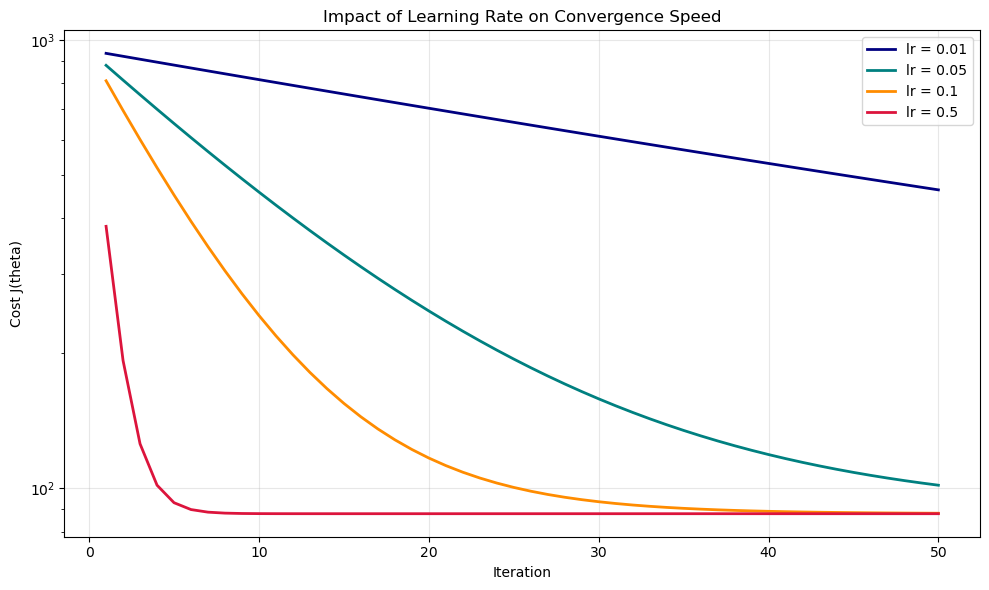

In [25]:
learning_rates = [0.01, 0.05, 0.1, 0.5]
colors = ['navy', 'teal', 'darkorange', 'crimson']
n_iter = 50

plt.figure(figsize=(10, 6))

for lr, color in zip(learning_rates, colors):
    _, cost_hist, _ = gradient_descent(
        X_b, y_flat, np.zeros(2), learning_rate=lr, n_iterations=n_iter
    )
    plt.plot(range(1, n_iter + 1), cost_hist, color=color, linewidth=2, label=f'lr = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Impact of Learning Rate on Convergence Speed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()


## 4. Stochastic Gradient Descent (SGD)

Instead of using the entire dataset to compute the gradient, SGD updates parameters using **one random example at a time**:

$$\theta := \theta - \alpha \left( h_\theta(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

**Pros:** Much faster per iteration; can escape shallow local minima.  
**Cons:** Noisy convergence — the cost oscillates near the minimum.


SGD — Intercept: 3.8342
SGD — Slope:     46.2399


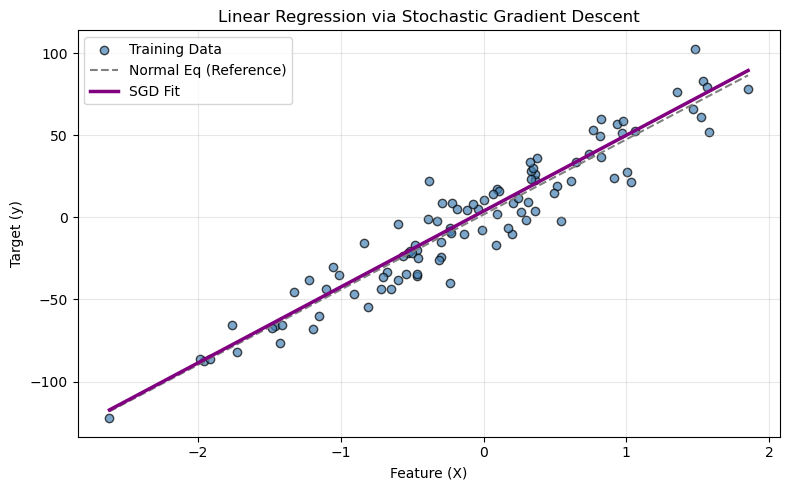

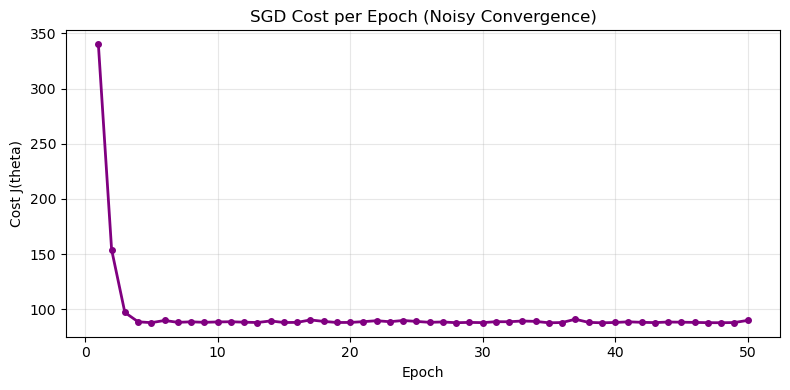

In [26]:
def stochastic_gradient_descent(X, y, theta_init, learning_rate=0.01, n_epochs=50):
    """Stochastic Gradient Descent."""
    m = len(y)
    theta = theta_init.copy()
    cost_history = []
    theta_history = []
    
    for epoch in range(n_epochs):
        for i in range(m):
            idx = np.random.randint(m)
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            gradient = xi.T @ (xi @ theta - yi)
            theta = theta - learning_rate * gradient.flatten()
        
        # Record cost after each full pass (epoch)
        cost_history.append(compute_cost(X, y, theta))
        theta_history.append(theta.copy())
        
    return theta, np.array(cost_history), np.array(theta_history)


# Run SGD
theta_sgd, cost_sgd, theta_hist_sgd = stochastic_gradient_descent(
    X_b, y_flat, np.zeros(2), learning_rate=0.01, n_epochs=50
)

print(f"SGD — Intercept: {theta_sgd[0]:.4f}")
print(f"SGD — Slope:     {theta_sgd[1]:.4f}")

# Plot SGD fit
plt.figure(figsize=(8, 5))
plt.scatter(X_flat, y_flat, c='steelblue', edgecolors='k', alpha=0.7, label='Training Data')
plt.plot(x_line, y_pred_normal, color='gray', linestyle='--', linewidth=1.5, label='Normal Eq (Reference)')
plt.plot(x_line, X_line_b @ theta_sgd, color='purple', linewidth=2.5, label='SGD Fit')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.title('Linear Regression via Stochastic Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SGD cost history (per epoch)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cost_sgd) + 1), cost_sgd, color='purple', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Cost J(theta)')
plt.title('SGD Cost per Epoch (Noisy Convergence)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Visualizing the Cost Surface

Linear regression's cost function $J(\theta)$ is convex — it has a single global minimum.  
Below we visualize:
1. A **contour plot** showing the GD optimization path.
2. A **3D surface** showing the bowl-shaped loss landscape.
3. 

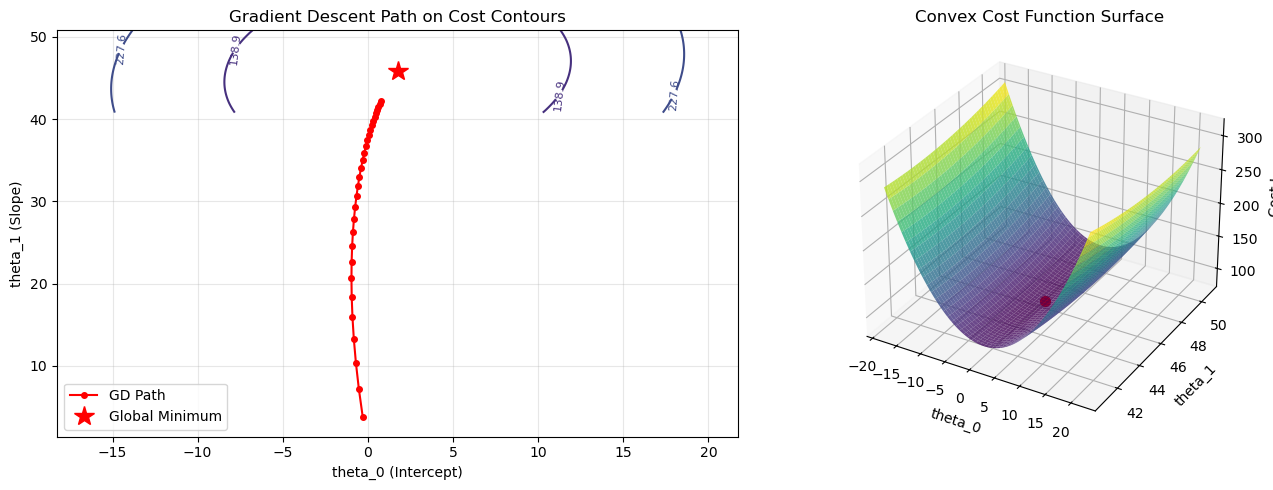

In [27]:
# Build cost surface grid
theta0_vals = np.linspace(theta_normal[0] - 20, theta_normal[0] + 20, 100)
theta1_vals = np.linspace(theta_normal[1] - 5, theta_normal[1] + 5, 100)
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        t = np.array([t0, t1])
        J_vals[i, j] = compute_cost(X_b, y_flat, t)

J_vals = J_vals.T  # transpose for contour alignment

# Run a short GD to capture the optimization path
_, _, theta_path = gradient_descent(
    X_b, y_flat, np.zeros(2), learning_rate=0.1, n_iterations=30
)

fig = plt.figure(figsize=(14, 5))

# --- Contour Plot ---
ax1 = fig.add_subplot(1, 2, 1)
contour = ax1.contour(
    theta0_vals, theta1_vals, J_vals, levels=np.logspace(0, 3, 15), cmap='viridis'
)
ax1.clabel(contour, inline=True, fontsize=8)
ax1.plot(theta_path[:, 0], theta_path[:, 1], 'r-', marker='o', markersize=4, label='GD Path')
ax1.plot(theta_normal[0], theta_normal[1], 'r*', markersize=15, label='Global Minimum')
ax1.set_xlabel('theta_0 (Intercept)')
ax1.set_ylabel('theta_1 (Slope)')
ax1.set_title('Gradient Descent Path on Cost Contours')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- 3D Surface ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
ax2.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8, edgecolor='none')
ax2.scatter(
    theta_normal[0], theta_normal[1],
    compute_cost(X_b, y_flat, theta_normal),
    color='red', s=50, label='Minimum'
)
ax2.set_xlabel('theta_0')
ax2.set_ylabel('theta_1')
ax2.set_zlabel('Cost J')
ax2.set_title('Convex Cost Function Surface')

plt.tight_layout()
plt.show()


## 6. Residual Analysis

After fitting, we examine the **residuals** (errors) to check model assumptions:
- **Random scatter** around zero in Residuals vs Fitted indicates linearity.
- **Bell-shaped histogram** suggests the noise is approximately Gaussian.

These diagnostics help validate whether linear regression is appropriate for the data.


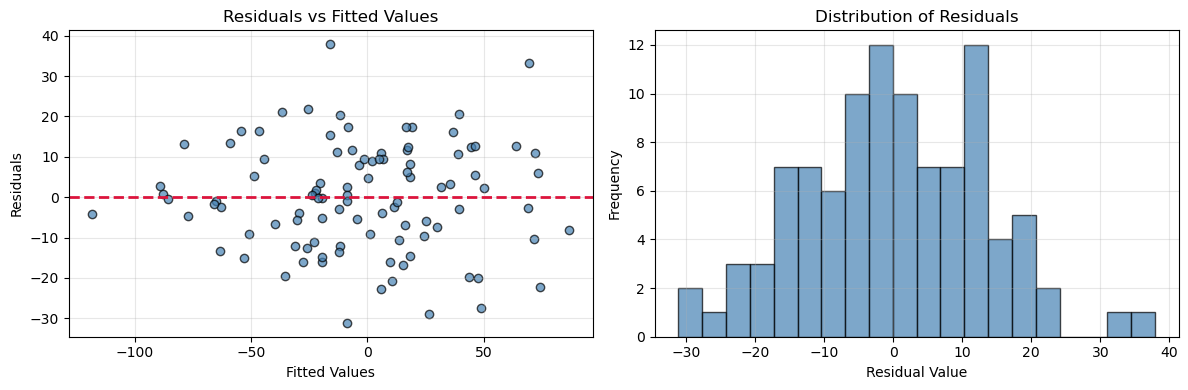

Mean of residuals: -0.000000
Std of residuals:  13.2522


In [28]:
# Predictions from Normal Equation for residual analysis
y_pred_all = X_b @ theta_normal
residuals = y_flat - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(y_pred_all, residuals, c='steelblue', edgecolors='k', alpha=0.7)
axes[0].axhline(y=0, color='crimson', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Mean of residuals: {np.mean(residuals):.6f}")
print(f"Std of residuals:  {np.std(residuals):.4f}")


## Summary

| Method | Type | Speed | Best For |
|--------|------|-------|----------|
| **Normal Equation** | Closed-form | Fast for small $n$ | Datasets with few features |
| **Batch GD** | Iterative | Slow per step, stable path | Medium datasets, smooth convergence |
| **SGD** | Iterative | Fast per step, noisy | Large datasets, online learning |

### Key Takeaways
- Linear regression minimizes a **convex** MSE loss — guaranteed global optimum.
- **Gradient Descent** scales better than the Normal Equation for high-dimensional data.
- The **learning rate** is the most critical hyperparameter for iterative methods.
- Always inspect **residuals** to validate model assumptions.
- 